Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

Anomaly detection is the process of identifying data points or patterns that deviate significantly from normal behavior in a dataset, often to detect faults, fraud, or rare events. It is widely used in domains like finance, cybersecurity, and healthcare to catch unusual patterns early.
​

Point anomalies
- A point anomaly is a single data point that is very different from the rest of the data.

- Example: Typical credit card transactions for a user are around ₹2,000–₹5,000, but one transaction suddenly appears for ₹2,00,000; this single transaction is a point anomaly and may indicate fraud.
​

Contextual anomalies
- A contextual anomaly is a data point that is normal in general, but abnormal in a specific context such as time, location, or season.

- Example: High network traffic is normal during office hours, but the same high traffic at midnight when the office is closed is a contextual anomaly and may indicate a security issue.
​

Collective anomalies
- A collective anomaly is a group of related data points that together form an unusual pattern, even if each point individually looks normal.

- Example: Several small but rapid consecutive failed login attempts across many accounts may seem fine individually, but together form a collective anomaly suggesting a coordinated attack.

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

solation Forest, DBSCAN, and Local Outlier Factor (LOF) are all unsupervised methods for anomaly detection, but they differ in how they define and find outliers and in the data situations where they work best.
​

Isolation Forest
- Approach: Uses an ensemble of random trees; points that get isolated in fewer splits (shorter path length) are considered anomalies.
​

- Best for: High-dimensional, large datasets, when you mainly care about global anomalies and need fast training and prediction.
​

DBSCAN
- Approach: Density-based clustering; finds dense regions as clusters and labels points that are not reachable from any dense region as noise (outliers).
​

- Best for: Data with well-separated clusters of similar density, arbitrary cluster shapes, and a need to detect outliers as “points not belonging to any cluster”.
​

Local Outlier Factor (LOF)
- Approach: Nearest-neighbor density comparison; assigns each point a score based on how much its local density deviates from that of its neighbors.
​

- Best for: Detecting local outliers in datasets where density varies across regions and global methods might miss subtle local anomalies.


Question 3: What are the key components of a Time Series? Explain each with one example.

Key components of a time series are trend, seasonality, cyclical component, and irregular/random component.
​

Trend
- Long-term upward or downward movement in the data.

- Example: Company revenue steadily increasing every year over 10 years.
​

Seasonality
- Regular, repeating pattern at fixed intervals (daily, weekly, yearly).

- Example: Ice-cream sales peaking every summer and dropping every winter.
​

Cyclical component
- Long-term up-and-down movements, not of fixed length, often linked to economic or business cycles.

- Example: Housing prices rising during a boom and falling during a recession over several years.
​

Irregular / random component
- Unpredictable, random fluctuations not explained by trend, seasonality, or cycles.

- Example: A sudden drop in sales in one month due to an unexpected strike or natural disaster

Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

A time series is stationary if its main statistical properties (mean, variance, and autocovariance structure) do not change over time; such a series has no trend or changing seasonality.
​

How to test stationarity
- Visual check: Plot the series and look for stable level and variance over time (no clear trend/seasonal pattern).
​

- Statistical tests: Use tests such as Augmented Dickey–Fuller (ADF) or KPSS to formally check for stationarity.
​

How to make a series stationary
- Differencing: Replace each value by the difference from the previous value (and, if needed, seasonal differencing like
y
t
−
y
t
−
12
y
t
 −y
t−12
 ).
​

- Transformations and detrending: Apply log or square-root transforms to stabilize variance, and remove trend/seasonality using regression or decomposition before modeling.


Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

AR Model
- Structure: Relies on p lagged values of the series:
y
t
=
c
+
∑
i
=
1
p
ϕ
i
y
t
−
i
+
ϵ
t
y
t
 =c+∑
i=1
p
 ϕ
i
 y
t−i
 +ϵ
t

- Application: Stationary series with autocorrelation from past values, e.g., short-term stock price dependencies.
​

MA Model
- Structure: Uses q lagged forecast errors:
y
t
=
c
+
ϵ
t
+
∑
j
=
1
q
θ
j
ϵ
t
−
j
y
t
 =c+ϵ
t
 +∑
j=1
q
 θ
j
 ϵ
t−j
 .

- Application: Capturing random shocks or noise in stationary data, e.g., economic indicators with temporary disturbances.
​

ARIMA Model
- Structure: Combines AR(p), MA(q), and differencing d: ARIMA(p,d,q) to handle non-stationarity.

- Application: Univariate forecasting with trends, e.g., GDP growth after differencing to achieve stationarity.
​

SARIMA Model
- Structure: Extends ARIMA with seasonal terms: SARIMA(p,d,q)(P,D,Q)s, adding seasonal AR/MA/differencing at period s.

- Application: Data with recurring seasonality, e.g., monthly sales peaking annually.
​

SARIMAX Model
- Structure: SARIMA plus exogenous regressors (X) for external variables.

- Application: Seasonal forecasting influenced by covariates, e.g., retail sales affected by promotions or holidays.




Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.
(Include your Python code and output in the code box below.)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the AirPassengers dataset
df = pd.read_csv('/content/AirPassengers.csv')

# Display the first few rows and info to understand the data structure
print(df.head())
print(df.info())

In [ ]:
# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Rename the passengers column for easier access
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Check the updated DataFrame
print(df.head())
print(df.info())

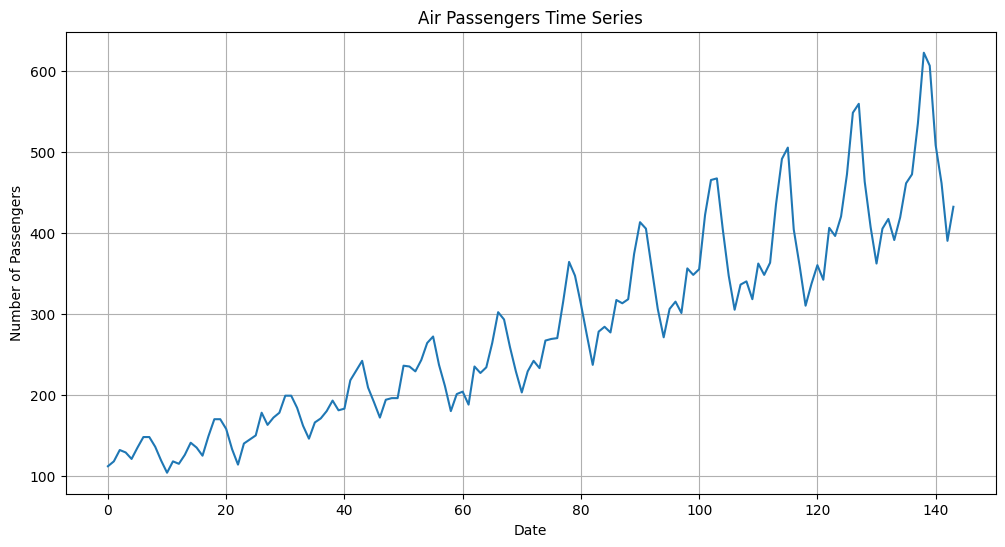

In [8]:
# Plot the original time series
plt.figure(figsize=(12, 6))
plt.plot(df['value'])
plt.title('Air Passengers Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.
(Include your Python code and output in the code box below.)

Generated synthetic dataset head:
   feature1  feature2
0 -7.338988 -7.729954
1 -7.740041 -7.264665
2 -1.686653  7.793442
3  4.422198  3.071947
4 -8.917752 -7.888196
Total data points: 350


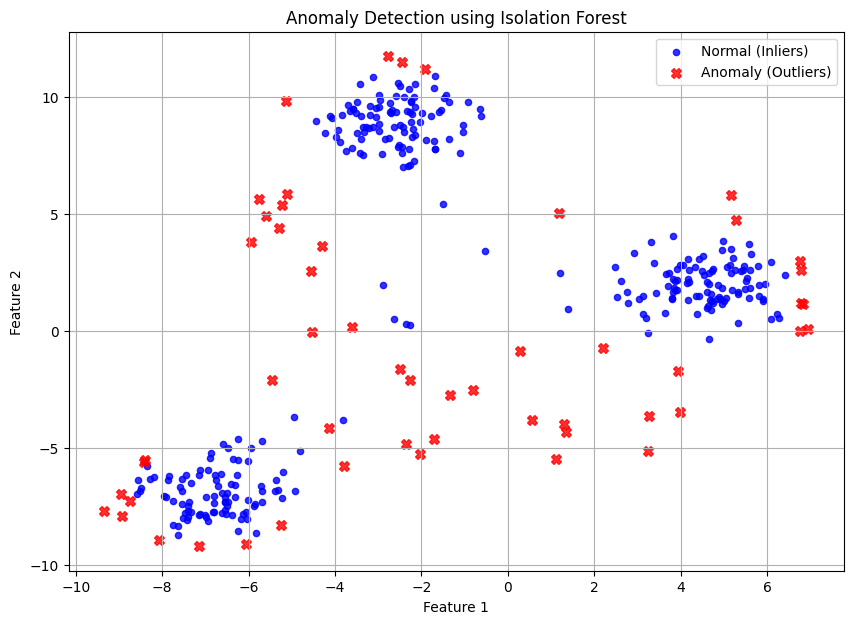

Number of detected anomalies: 53


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

# 1. Generate a synthetic dataset with anomalies
# Generate some normal data points (clusters)
X, _ = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Introduce some anomalous data points
rng = np.random.RandomState(42)
X_outliers = rng.uniform(low=-6, high=6, size=(50, 2))

# Combine normal and anomalous data
X = np.concatenate([X, X_outliers], axis=0)
df = pd.DataFrame(X, columns=['feature1', 'feature2'])

print("Generated synthetic dataset head:")
print(df.head())
print(f"Total data points: {len(df)}")

# 2. Apply Isolation Forest
# `n_estimators`: number of base estimators (trees) in the ensemble
# `contamination`: the proportion of outliers in the dataset (an estimate)
model = IsolationForest(n_estimators=100, contamination=0.15, random_state=42, verbose=0, n_jobs=-1)
model.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
df['anomaly'] = model.predict(X)

# 3. Visualize the anomalies on a 2D scatter plot
plt.figure(figsize=(10, 7))

# Plot inliers (normal points)
plt.scatter(df[df['anomaly'] == 1]['feature1'],
            df[df['anomaly'] == 1]['feature2'],
            c='blue', label='Normal (Inliers)', s=20, alpha=0.8)

# Plot outliers (anomalies)
plt.scatter(df[df['anomaly'] == -1]['feature1'],
            df[df['anomaly'] == -1]['feature2'],
            c='red', label='Anomaly (Outliers)', s=50, marker='X', alpha=0.8)

plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of detected anomalies: {len(df[df['anomaly'] == -1])}")

Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.
(Include your Python code and output in the code box below.)

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' DataFrame from previous steps is available and contains 'Passengers' indexed by 'Month'
# Define the SARIMA model parameters (p,d,q)(P,D,Q,s)
# A common set of parameters for the AirPassengers dataset is (1,1,1)(1,1,1,12)
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12) # (P, D, Q, S) where S=12 for monthly data

# Create and fit the SARIMA model
model = SARIMAX(df['Passengers'], order=order, seasonal_order=seasonal_order)
sarima_results = model.fit(disp=False)

print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Tue, 30 Dec 2025   AIC                           1022.299
Time:                                    13:38:05   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

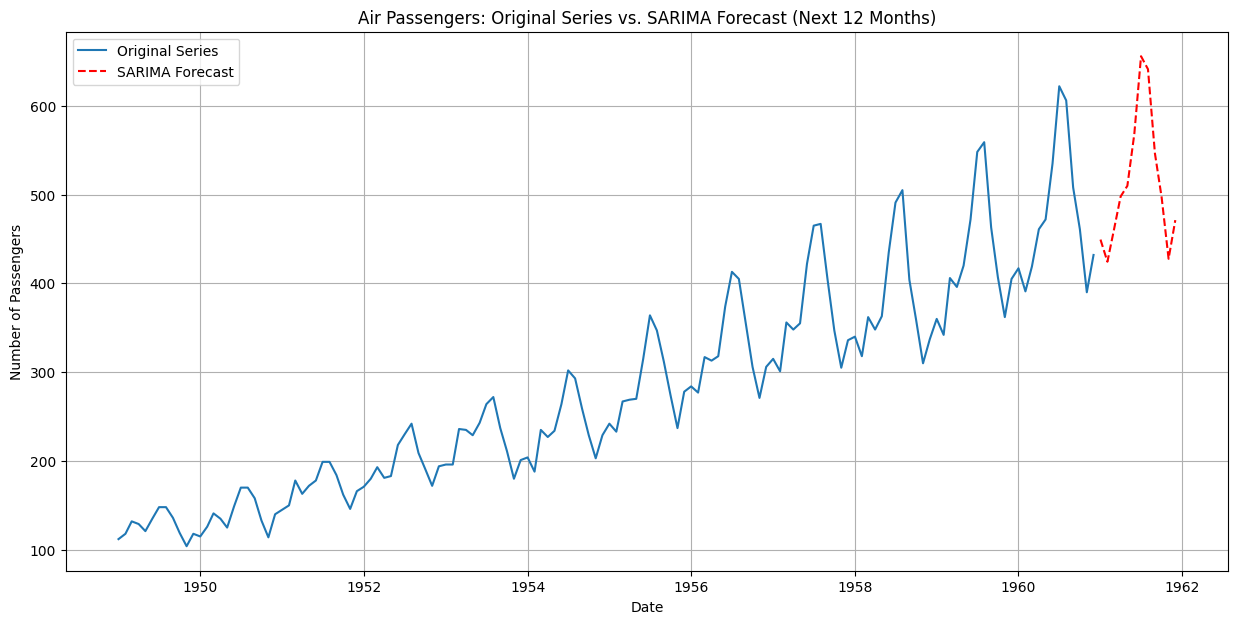

In [19]:
# Get the forecast for the next 12 months
# We need to determine the start and end dates for the forecast.
# The last date in our original dataset is df.index[-1].
# We want to forecast for the next 12 months, so we can calculate the end date.

last_date = df.index[-1]
forecast_start = last_date + pd.DateOffset(months=1)
forecast_end = last_date + pd.DateOffset(months=12)

forecast = sarima_results.predict(start=forecast_start, end=forecast_end, dynamic=False)

# Create a date range for the forecast for plotting purposes
forecast_index = pd.date_range(start=forecast_start, periods=12, freq='MS')
forecast_series = pd.Series(forecast, index=forecast_index)

# Plot the original series and the forecast
plt.figure(figsize=(15, 7))
plt.plot(df['Passengers'], label='Original Series')
plt.plot(forecast_series, label='SARIMA Forecast', color='red', linestyle='--')
plt.title('Air Passengers: Original Series vs. SARIMA Forecast (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import numpy as np

# Load the NYC Taxi Fare dataset
try:
    df_taxi = pd.read_csv('/content/NYC_taxi_fare_data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: NYC_taxi_fare_data.csv not found. Please ensure the file is in the correct path.")
    # Exit or handle the error appropriately
    exit()

# Display the first few rows and info
print(df_taxi.head())
print(df_taxi.info())

Dataset loaded successfully.
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2020-01-01 00:28:15   2020-01-01 00:33:03                1   
1         1  2020-01-01 00:35:39   2020-01-01 00:43:04                1   
2         1  2020-01-01 00:47:41   2020-01-01 00:53:52                1   
3         1  2020-01-01 00:55:23   2020-01-01 01:00:14                1   
4         2  2020-01-01 00:01:58   2020-01-01 00:04:16                1   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.2           1                  N           238           239   
1            1.2           1                  N           239           238   
2            0.6           1                  N           238           238   
3            0.8           1                  N           238           151   
4            0.0           1                  N           193           193   

   payment_type  fare_amount  extra  mta_tax 

In [21]:
# Select relevant features for anomaly detection and clean data
features = ['fare_amount', 'trip_distance']
df_filtered = df_taxi.dropna(subset=features).copy()

# Filter out non-positive fare amounts and trip distances as they are likely errors
df_filtered = df_filtered[df_filtered['fare_amount'] > 0]
df_filtered = df_filtered[df_filtered['trip_distance'] > 0]

# For visualization, we'll use a sample if the dataset is too large
# to avoid plotting issues and memory consumption.
# Let's limit to 100,000 rows for faster processing and clear visualization if the dataset is huge
if len(df_filtered) > 100000:
    df_sample = df_filtered.sample(n=100000, random_state=42)
else:
    df_sample = df_filtered

X = df_sample[features]

print(f"Shape of data after filtering: {df_sample.shape}")
print(df_sample.describe())

Shape of data after filtering: (100000, 18)
            VendorID  passenger_count  trip_distance     RatecodeID  \
count  100000.000000    100000.000000  100000.000000  100000.000000   
mean        1.699480         1.644970       3.510468       1.066360   
std         0.458486         1.221998       4.336263       0.714046   
min         1.000000         0.000000       0.010000       1.000000   
25%         1.000000         1.000000       1.100000       1.000000   
50%         2.000000         1.000000       1.900000       1.000000   
75%         2.000000         2.000000       3.810000       1.000000   
max         2.000000         8.000000      76.310000      99.000000   

        PULocationID  DOLocationID   payment_type    fare_amount  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean      158.075530     155.46710       1.355890      13.648072   
std        67.595414      72.29191       0.496079      12.996965   
min         1.000000       1.00000       1.0

In [22]:
# Initialize and train the Isolation Forest model
# contamination: the proportion of outliers in the dataset.
#                 This is used when training the model to estimate the number of outliers.
iso_forest = IsolationForest(random_state=42, contamination=0.01)
iso_forest.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
df_sample['anomaly'] = iso_forest.predict(X)

# Get anomaly scores (lower score means more anomalous)
df_sample['anomaly_score'] = iso_forest.decision_function(X)

# Separate anomalies and normal points
anomalies = df_sample[df_sample['anomaly'] == -1]
normal_points = df_sample[df_sample['anomaly'] == 1]

print(f"Number of detected anomalies: {len(anomalies)}")
print(f"Number of normal points: {len(normal_points)}")

Number of detected anomalies: 999
Number of normal points: 99001


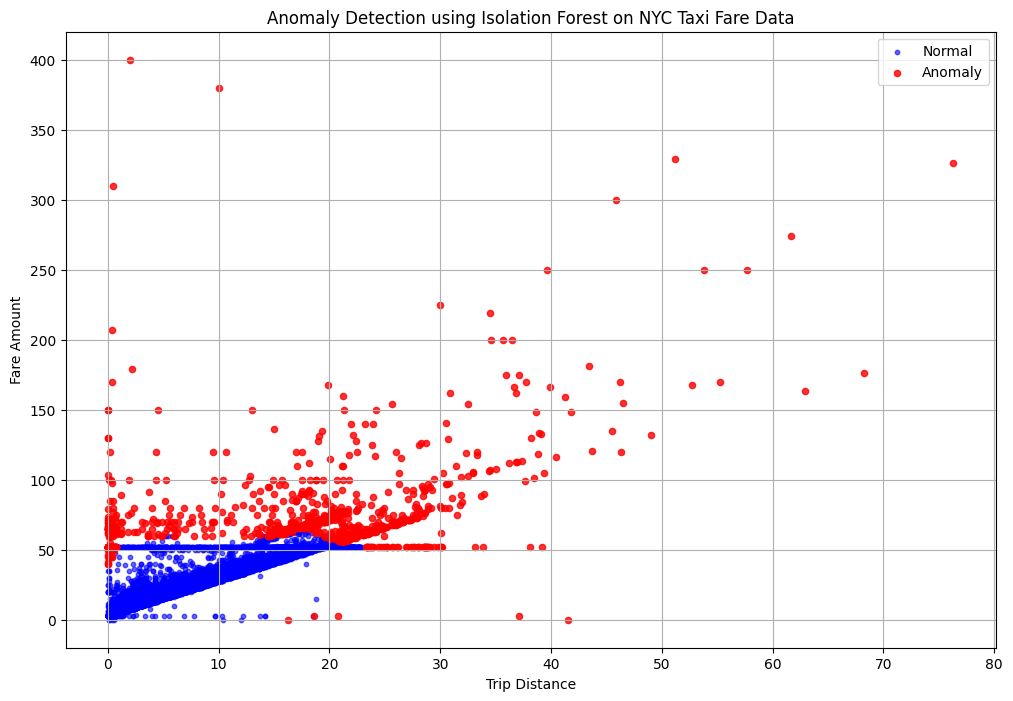

In [23]:
# Visualize the anomalies
plt.figure(figsize=(12, 8))
plt.scatter(normal_points['trip_distance'], normal_points['fare_amount'],
            c='blue', label='Normal', s=10, alpha=0.6)
plt.scatter(anomalies['trip_distance'], anomalies['fare_amount'],
            c='red', label='Anomaly', s=20, alpha=0.8)

plt.title('Anomaly Detection using Isolation Forest on NYC Taxi Fare Data')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.legend()
plt.grid(True)
plt.show()

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.
(Include your Python code and output in the code box below.)

Generated synthetic dataset head:
   feature1  feature2
0  1.404348  2.328277
1  1.727809  2.055461
2 -1.939852 -1.742781
3  1.509246  2.231052
4  2.029104  1.428515
Total data points: 330
Number of detected anomalies: 33
Number of normal points: 297


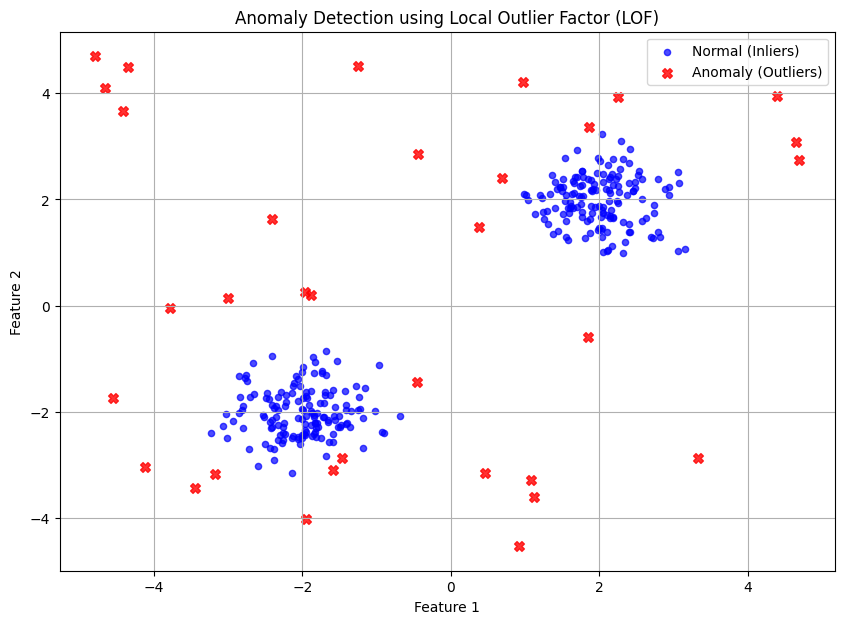

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# 1. Generate a synthetic dataset with anomalies
# Generate some normal data points (clusters)
X_inliers, _ = make_blobs(n_samples=300, centers=[[2, 2], [-2, -2]], cluster_std=0.5, random_state=42)

# Introduce some anomalous data points
rng = np.random.RandomState(42)
X_outliers = rng.uniform(low=-5, high=5, size=(30, 2))

# Combine normal and anomalous data
X = np.concatenate([X_inliers, X_outliers], axis=0)
df_lof = pd.DataFrame(X, columns=['feature1', 'feature2'])

print("Generated synthetic dataset head:")
print(df_lof.head())
print(f"Total data points: {len(df_lof)}")

# 2. Apply Local Outlier Factor (LOF)
# `n_neighbors`: number of neighbors to consider for local density
# `contamination`: the proportion of outliers in the dataset (an estimate)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1, novelty=False)

# Fit the model and predict (LOF returns -1 for outliers, 1 for inliers)
df_lof['anomaly_score'] = lof.fit_predict(X)

# Get the raw LOF scores (lower is more anomalous for `novelty=False`)
df_lof['raw_lof_score'] = lof.negative_outlier_factor_

# Separate anomalies and normal points based on prediction
anomalies_lof = df_lof[df_lof['anomaly_score'] == -1]
normal_points_lof = df_lof[df_lof['anomaly_score'] == 1]

print(f"Number of detected anomalies: {len(anomalies_lof)}")
print(f"Number of normal points: {len(normal_points_lof)}")

# 3. Visualize the anomalies on a 2D scatter plot
plt.figure(figsize=(10, 7))

# Plot normal points
plt.scatter(normal_points_lof['feature1'], normal_points_lof['feature2'],
            c='blue', label='Normal (Inliers)', s=20, alpha=0.7)

# Plot anomalies
plt.scatter(anomalies_lof['feature1'], anomalies_lof['feature2'],
            c='red', label='Anomaly (Outliers)', s=50, marker='X', alpha=0.8)

plt.title('Anomaly Detection using Local Outlier Factor (LOF)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Question 10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:

● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?

● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?

● How would you validate and monitor the performance over time?

● How would this solution help business decisions or operations?






### Real-time Data Science Workflow for Power Grid Monitoring

#### **1. Anomaly Detection in Streaming Data**

For real-time anomaly detection in 15-minute consumption data, a hybrid approach or careful selection based on data characteristics would be crucial.

*   **Isolation Forest:**
    *   **Approach:** This is an ensemble method based on decision trees. It works by randomly partitioning data and identifying anomalies as points that are isolated quickly (i.e., with fewer splits). Anomalies are 'few and different' and thus more susceptible to isolation.
    *   **Suitability for Real-time Power Grid:**
        *   **Pros:** Highly efficient for high-dimensional datasets and works well with large data streams due to its tree-based nature (can process chunks of data). It's generally fast for both training and prediction. Good for global anomalies (e.g., a massive, sudden power surge or drop).
        *   **Cons:** Can be sensitive to hyperparameter tuning, especially `contamination`. It might struggle with subtle, local anomalies or anomalies that aren't easily isolated in hyper-rectangles. Needs a good understanding of the expected anomaly proportion.
    *   **Implementation Note:** For streaming data, you'd typically train the model periodically on recent historical data and then use it to predict on incoming data points. An online version or mini-batch retraining could be considered.

*   **Local Outlier Factor (LOF):**
    *   **Approach:** LOF measures the local deviation of density of a given data point with respect to its neighbors. It considers as outliers those samples that have a substantially lower density than their neighbors.
    *   **Suitability for Real-time Power Grid:**
        *   **Pros:** Excellent for detecting *local* anomalies, which might be crucial in a power grid where 'normal' behavior can vary significantly by region or time of day (e.g., an unusual spike in one substation might be normal in another). It doesn't assume a global distribution.
        *   **Cons:** Computationally more expensive than Isolation Forest, especially as the number of neighbors (`k`) increases. This can be a challenge with high-velocity real-time data. It's more memory-intensive as it needs to store neighbor distances.
    *   **Implementation Note:** Due to its computational cost, LOF might be better suited for offline analysis of recent data batches, or for a smaller, more critical subset of features/regions, rather than on every single incoming data point in a very high-frequency stream.

*   **DBSCAN:**
    *   **Approach:** A density-based clustering algorithm that groups together closely packed data points (neighbors) and marks as outliers those points that lie alone in low-density regions. It defines points as core, border, or noise (outlier).
    *   **Suitability for Real-time Power Grid:**
        *   **Pros:** Can find arbitrarily shaped clusters and doesn't require pre-defining the number of clusters. Very effective at identifying anomalies as 'noise' that don't belong to any dense region. Useful for identifying abnormal *patterns* of usage.
        *   **Cons:** Not directly designed for streaming data; it's a batch-processing algorithm. Sensitive to its two main parameters (`epsilon` and `min_samples`), which can be hard to set in dynamic environments. Density can vary across different regions/times, making global parameters difficult.
    *   **Implementation Note:** DBSCAN would likely be used in an *offline* or *periodic batch* manner. You could run DBSCAN on a window of recent data (e.g., last hour, last day) to identify anomalous clusters or points that emerge over time, rather than detecting single-point anomalies in real-time.

**Recommendation for Real-time Power Grid Anomaly Detection:**

Given the need for *real-time* detection, a tiered or hybrid approach would be most robust:

1.  **Initial Real-time Filter (Isolation Forest):** For immediate detection of significant global deviations. Its speed and scalability make it suitable for a first pass on the 15-minute data stream. Thresholds could be set to flag high-severity anomalies instantly.
2.  **Secondary Analysis (LOF/DBSCAN on Batches):** Periodically, a larger window of recent data (e.g., last 24 hours, last week) could be processed using LOF or DBSCAN. This would catch more subtle, local anomalies or emerging anomalous patterns that Isolation Forest might miss due to its global nature. This could run in parallel, providing deeper insights without impacting real-time alerts.
3.  **Contextual Anomaly Detection:** Integrate region, weather conditions, and time-of-day features. Anomalies are often contextual. For example, a sudden drop in energy usage might be normal during a holiday but anomalous during a regular workday. Pre-processing to normalize data by context or using models that inherently handle contextual features (e.g., deep learning models with recurrent layers) would be beneficial.

This multi-model strategy ensures both rapid response to critical events and comprehensive detection of complex, evolving anomalies.